# Survival Analysis and Censored Data Tutorial with Numpyro
This notebook provides an illustrative walkthrough of modeling censored data in survival analysis using Numpyro.

**Goals:**
- Understand different types of censoring: right, left, and interval.
- Learn how to simulate censored datasets.
- Apply probabilistic models to censored data using Numpyro's built-in distributions.
- Compare naive and censored models to see the impact of ignoring censoring.

**Background:**
Censored data is common in survival analysis, reliability engineering, and clinical trials. Properly modeling censoring is crucial for unbiased parameter estimation.

**References:**
- [Survival Analysis Wikipedia](https://en.wikipedia.org/wiki/Survival_analysis)
- [Numpyro Documentation](https://num.pyro.ai/en/stable/)
- [Pyro Survival Analysis Tutorial](https://pyro.ai/examples/survival.html)

# Censored data and Survival Analysis with Numpyro

This notebook demonstrates how to handle censored data using Numpyro.
Censoring occurs when the value of a measurement is only partially known. In survival analysis, for example, we might know that a patient survived for at least a certain amount of time, but not the exact time of death.
This is called 'right-censoring'. Similarly, 'left-censoring' occurs when we know that a value is below a certain threshold, and 'interval-censoring' occurs when we know that a value lies within a certain range.
We will use `RightCensoredDistribution`, `LeftCensoredDistribution`, and `IntervalCensoredDistribution` from `numpyro.distributions` to model such data.

In [1]:
# Import required libraries for survival analysis and censored data modeling.
# Numpyro provides specialized distributions for handling censored observations.
# We will use pandas for data manipulation, JAX for numerical operations, and matplotlib for visualization.

import pandas as pd

import jax
from jax import numpy as jnp, random

import numpyro
from numpyro import distributions as dist
from numpyro.distributions import (
    IntervalCensoredDistribution,
    LeftCensoredDistribution,
    RightCensoredDistribution,
    TruncatedDistribution
)
from numpyro.infer.hmc import NUTS
from numpyro.infer.mcmc import MCMC

import matplotlib.pyplot as plt

# Set up Numpyro to use multiple CPU cores for faster MCMC sampling.
numpyro.set_host_device_count(4)

## Parameter Retrieval Simulations
In this section, we simulate right-censored data and demonstrate how to recover model parameters using both naive and censored approaches.

### Right-Censored Data: Real Support
Right-censoring occurs when we know an observation exceeds a certain threshold, but not its exact value. This is common in survival analysis when the event of interest (e.g., failure, death) has not occurred by the end of the study period.

We will:
- Generate synthetic data with right-censoring.
- Visualize the effect of censoring.
- Fit both naive and censored models to compare results.

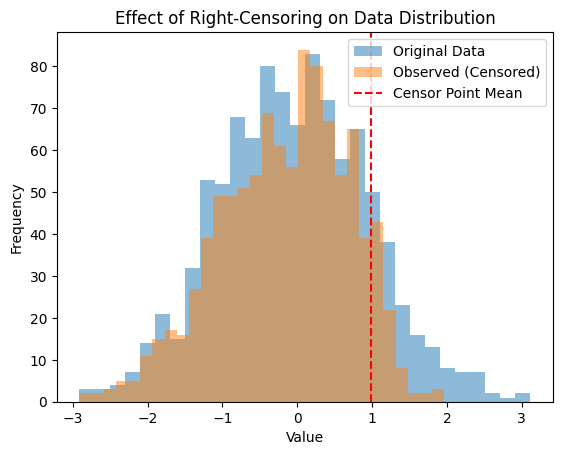

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

Naive model (ignores censoring):

                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu     -0.16      0.03     -0.17     -0.21     -0.12   6671.64      1.00
     sigma      0.86      0.02      0.86      0.83      0.89   7726.46      1.00

Number of divergences: 0
None
Censored model (accounts for censoring):

                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu     -0.06      0.03     -0.06     -0.11     -0.01   6414.22      1.00
     sigma      0.99      0.03      0.99      0.95      1.03   7165.98      1.00

Number of divergences: 0
None

                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu     -0.06      0.03     -0.06     -0.11     -0.01   6414.22      1.00
     sigma      0.99      0.03      0.99      0.95      1.03   7165.98      1.00

Number of divergences: 0
None


In [2]:
## Simulate right-censored data and compare models
rng_key = random.PRNGKey(0)
key_x, key_censor = random.split(rng_key)
n = 1000  # Number of samples

# Generate original data from a Normal distribution
x_orig = dist.Normal(0, 1).sample(key_x, (n,))
censor_point = dist.Normal(1, 0.5).sample(key_censor, (n,))  # Censoring threshold
is_censored = x_orig > censor_point  # Boolean mask for censored observations
x_observed = jnp.where(is_censored, censor_point, x_orig)  # Observed data: censored values replaced by threshold

# Visualize original and observed (censored) data
plt.hist(x_orig, bins=30, alpha=0.5, label='Original Data')
plt.hist(x_observed, bins=30, alpha=0.5, label='Observed (Censored)')
plt.axvline(censor_point.mean(), color='r', linestyle='--', label='Censor Point Mean')
plt.legend()
plt.title('Effect of Right-Censoring on Data Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

# Naive model: ignores censoring, treats all data as observed
def model_naive(x):
    mu = numpyro.sample("mu", dist.Normal(0, 10))
    sigma = numpyro.sample("sigma", dist.HalfCauchy(5))
    with numpyro.plate("data", x.shape[0]):
        numpyro.sample("obs", dist.Normal(mu, sigma), obs=x)

# Censored model: uses RightCensoredDistribution to account for censored observations
def model_censored(x, censored):
    mu = numpyro.sample("mu", dist.Normal(0, 10))
    sigma = numpyro.sample("sigma", dist.HalfCauchy(5))
    with numpyro.plate("data", x.shape[0]):
        base_dist = dist.Normal(mu, sigma)
        censored_dist = RightCensoredDistribution(base_dist, censored=censored)
        numpyro.sample("obs", censored_dist, obs=x)

# Run MCMC for both models and print summaries
mcmc_naive = MCMC(NUTS(model_naive), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_naive.run(rng_key, x_observed)
mcmc_censored = MCMC(NUTS(model_censored), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_censored.run(rng_key, x_observed, is_censored)
print("Naive model (ignores censoring):")
print(mcmc_naive.print_summary())
print("Censored model (accounts for censoring):")
print(mcmc_censored.print_summary())

## Interval-Censored Data Example: Real Support
Interval censoring occurs when the true value is only known to lie within a specific interval. This is common when measurements are taken at discrete time points, and the event occurs between two observations.

In this section:
- We simulate interval-censored data.
- Show how to encode left, right, and interval censoring.
- Fit a model using `IntervalCensoredDistribution`.

In [3]:
# Simulate interval-censored data
rng_key = random.PRNGKey(1)

kx, kl, kr = random.split(rng_key, 3)
x_orig = dist.Normal(0,1).sample(kx, (1000,))
left = dist.Normal(-1, 0.5).sample(kl, (1000,))  # Left censoring threshold
right = dist.Normal(1.5, .25).sample(kr, (1000,))  # Right censoring threshold

# Initialize censoring bounds
min_val = -jnp.inf
max_val = jnp.inf

x1 = jnp.full(x_orig.shape, min_val)  # Lower bound
x2 = jnp.full(x_orig.shape, max_val)  # Upper bound

# Apply censoring logic
x1 = jnp.where(x_orig > right, right, x1)  # Right censored
x2 = jnp.where(x_orig < left, left, x2)  # Left censored
# Interval censored: value is between left and right
x1 = jnp.where((x_orig >= left) & (x_orig <= right), left, x1)
x2 = jnp.where((x_orig >= left) & (x_orig <= right), right, x2)

x = jnp.stack([x1, x2], axis=-1)  # Observed intervals

left_censored = x_orig < left
right_censored = x_orig > right
censor_type = jnp.where(x_orig < left, -1, 0)  # left censored
censor_type = jnp.where(x_orig > right, 1, censor_type)  # right censored
censor_type = jnp.where((x_orig >= left) & (x_orig <= right), 2, censor_type)  # interval censored

# Store results in a DataFrame for inspection
df = pd.DataFrame(dict(x=x_orig, left=left, right=right, x1=x1, x2=x2, censor_type=censor_type))
df.censor_type = df.censor_type.map({-1: 'left', 0: 'observed', 1: 'right', 2: 'interval'})

# Model for interval-censored data
def model_interval(x, left_censored, right_censored):
    loc = numpyro.sample("loc", dist.Normal(0, 10))
    scale = numpyro.sample("scale", dist.HalfNormal(10))

    with numpyro.plate("data", len(x)):
        base_dist = dist.Normal(loc, scale)
        cens_dist = IntervalCensoredDistribution(base_dist, left_censored, right_censored)
        numpyro.sample("obs", cens_dist, obs=x)

# Run MCMC and print summary
mcmc_interval = MCMC(
    NUTS(model_interval), num_warmup=1000, num_samples=2000, num_chains=4
)
mcmc_interval.run(rng_key, x, left_censored, right_censored)
mcmc_interval.print_summary()

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       loc     -0.05      0.04     -0.05     -0.12      0.01   6282.34      1.00
     scale      1.00      0.03      1.00      0.95      1.05   6830.71      1.00

Number of divergences: 0


## Right-Censored Weibull Example
The Weibull distribution is widely used in survival analysis and reliability engineering to model time-to-event data.

In this section:
- We simulate survival times from a Weibull distribution.
- Apply right-censoring to a subset of the data.
- Fit a censored Weibull model using Numpyro.
- Discuss how censoring affects parameter estimation.

In [4]:
# Simulate right-censored survival times from a Weibull distribution
scale = 1.0  # True scale parameter
concentration = 2.0  # True shape parameter
censor_prob = 0.2  # Probability of censoring
n = 1000  # Number of samples

key = random.PRNGKey(0)
key_time, key_censor, key = random.split(key, 3)
wb = dist.Weibull(scale, concentration)
times = wb.sample(key_time, (n,))  # Simulated survival times
is_censored = dist.Bernoulli(censor_prob).sample(key_censor, (n,))  # Censoring indicator

# Create a censored Weibull distribution for modeling
wbc = RightCensoredDistribution(wb, censored=is_censored)

# Save simulated data for inspection or reuse
df = pd.DataFrame({"times": times, "is_censored": is_censored})
df.to_csv("survival_data.csv", index=False)

# Model definition for censored Weibull data
def model(times, is_censored):
    scale = numpyro.sample("scale", dist.HalfNormal(10))
    concentration = numpyro.sample("concentration", dist.HalfNormal(10))
    wb = dist.Weibull(scale, concentration)
    wbc = RightCensoredDistribution(wb, censored=is_censored)
    numpyro.sample("obs", wbc, obs=times)

In [6]:
def model(times, is_censored):
    scale = numpyro.sample("scale", dist.HalfNormal(10))
    concentration = numpyro.sample("concentration", dist.HalfNormal(10))
    wb = dist.Weibull(scale, concentration)
    wbc = RightCensoredDistribution(wb, censored=is_censored)
    numpyro.sample("obs", wbc, obs=times)

In [7]:
# Run MCMC to fit the censored Weibull model and print summary
mcmc = MCMC(NUTS(model), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc.run(key, times, is_censored)
mcmc.print_summary()
# Interpretation: Compare estimated parameters to true values (scale=1.0, concentration=2.0) to assess model performance under censoring.

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
  concentration      1.98      0.06      1.98      1.89      2.08   5800.39      1.00
          scale      1.11      0.02      1.11      1.08      1.15   7574.78      1.00

Number of divergences: 0


## Censored Normal Distribution Examples
Censoring can occur in many distributions, not just Weibull. Here we show how to handle right- and left-censored data from a Normal (or HalfNormal) distribution.

We will:
- Simulate right- and left-censored data.
- Fit naive and censored models.
- Compare parameter estimates to highlight the impact of ignoring censoring.

In [8]:
# Naive model for censored normal data: ignores censoring
def model_naive(x):
    scale = numpyro.sample("scale", dist.HalfNormal(10))
    with numpyro.plate("data", len(x)):
        numpyro.sample("obs", dist.HalfNormal(scale), obs=x)

In [9]:
# Simulate right-censored data from a HalfNormal distribution
rng_key = random.PRNGKey(1)
kx, kc = random.split(rng_key)
x_orig = dist.HalfNormal(1).sample(kx, (100,))  # True data
tc = dist.HalfNormal(2).sample(kc, (100,))  # Censoring threshold
c = x_orig > tc  # Censoring indicator
x = jnp.where(c, tc, x_orig)  # Observed data

# Model that accounts for right-censoring
def model2(x, c):
    scale = numpyro.sample("scale", dist.HalfNormal(10))
    cens_dist = RightCensoredDistribution(dist.HalfNormal(scale), censored=c)
    numpyro.sample("obs", cens_dist, obs=x)

# Run MCMC for both models and compare results
mcmc2 = MCMC(NUTS(model2), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc2.run(rng_key, x, c)
mcmc2.print_summary()

mcmc_naive = MCMC(NUTS(model_naive), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_naive.run(rng_key, x)
mcmc_naive.print_summary()
# Interpretation: The censored model should provide less biased estimates than the naive model.

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      1.04      0.09      1.04      0.89      1.19   2658.07      1.00

Number of divergences: 0


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      0.84      0.06      0.83      0.73      0.93   2563.24      1.00

Number of divergences: 0


### Left-Censored Data Example
Left-censoring occurs when we only know that an observation is below a certain threshold. This is common in detection limit scenarios (e.g., measurements below a device's sensitivity).
Here, we simulate left-censored data and fit both naive and censored models.

In [10]:
# Simulate left-censored data from a HalfNormal distribution
rng_key = random.PRNGKey(1)
kx, kc = random.split(rng_key)
x_orig = dist.HalfNormal(2).sample(kx, (100,))  # True data
tc = dist.HalfNormal(1.5).sample(kc, (100,))  # Censoring threshold
c = x_orig < tc  # Censoring indicator
x = jnp.where(c, tc, x_orig)  # Observed data

# Model that accounts for left-censoring
def model_left(x, c):
    scale = numpyro.sample("scale", dist.HalfNormal(10))
    cens_dist = LeftCensoredDistribution(dist.HalfNormal(scale), censored=c)
    numpyro.sample("obs", cens_dist, obs=x)

# Run MCMC for both models and compare results
mcmc_left = MCMC(NUTS(model_left), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_left.run(rng_key, x, c)
mcmc_left.print_summary()

mcmc_naive = MCMC(NUTS(model_naive), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_naive.run(rng_key, x)
mcmc_naive.print_summary()
# Interpretation: The censored model should provide more accurate estimates when left-censoring is present.

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      2.07      0.15      2.06      1.82      2.32   2559.29      1.00

Number of divergences: 0


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      2.36      0.17      2.35      2.06      2.63   2728.73      1.00

Number of divergences: 0
